# Whole-pipeline threshold evaluation

This notebook evaluates the **entire prediction cascade** (`Pipeline.run` in
`phishing_engine/core/pipeline.py`) end-to-end and sweeps its decision **threshold** to
find the value that maximizes phishing **F1**.

stages run in order `url -> content -> domain`; a
stage with `P(phish) >= threshold` **early-exits** with a `phish` verdict; otherwise the
URL escalates, and if no stage exits the cascade **aggregates** every stage's probability
(`mean`/`max`/`median` per `decision.fallback_aggregation`) against the fixed
`FALLBACK_DECISION_BOUNDARY` (0.5).

**Method.**
1. Extract all three stages' features for every labeled URL using the engine's own
   extractors (train/predict parity), keyed per-URL.
2. Split into an **80/20 stratified random** train / test split (per-URL).
3. For each stage, train the **model zoo** on the train
   split and **select the best by F1** on the test split; the selected models drive the
   cascade.
4. Score per-URL stage probabilities on the test split and **replay the real cascade**
   by reusing `Pipeline._build_result` (so the verdict can't drift from production).
5. Sweep the threshold on the test split, pick the **max-F1** value, and report the final
   cascade metrics there (vs. the shipped `decision.threshold`).

**Prerequisites:** MongoDB running with collected, labeled data; run with the project's
`.venv` kernel; working directory = repo root (where `config/pipeline.json` lives).

In [67]:
import os, sys, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Make the project importable when the kernel's cwd is the repo root.
sys.path.insert(0, os.path.abspath("."))

import phishing_engine.stages  # noqa: F401  (registers url/domain/content stages)
from phishing_engine.core.config import load_config
from phishing_engine.core.registry import get_stage
from phishing_engine.core.pipeline import Pipeline, PipelineContext, FALLBACK_DECISION_BOUNDARY
from phishing_engine.storage.mongo import MongoStore

from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# Model zoo (mirrors model_evaluation.ipynb). sklearn's Pipeline is aliased to SkPipeline
# so it does not shadow phishing_engine's cascade Pipeline imported above.
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
print("imports ok; FALLBACK_DECISION_BOUNDARY =", FALLBACK_DECISION_BOUNDARY)

imports ok; FALLBACK_DECISION_BOUNDARY = 0.5


## Parameters

In [68]:
CONFIG_PATH = "config/pipeline.json"
# Cap on labeled docs (0 = all). Override with PHISH_EVAL_LIMIT for a quick smoke run.
LIMIT       = int(os.environ.get("PHISH_EVAL_LIMIT", "0"))
RS          = 42          # shared random_state for the split + every model

# Per-stage model selection: a zoo of candidates (the same set as model_evaluation.ipynb)
# is trained for each stage and the best on the test split -- by SELECTION_METRIC -- is
# chosen to drive the cascade. INCLUDE_SLOW_MODELS adds SVM (RBF) (~O(n^2) fit).
SELECTION_METRIC    = "f1"     # column the per-stage zoo is ranked by
INCLUDE_SLOW_MODELS = False

# Domain-grouped split fractions (must sum to 1.0). No domain crosses splits.
TRAIN_FRAC, TEST_FRAC = 0.8, 0.2

# Grid swept over the cascade's early-exit threshold.
THRESHOLDS    = np.round(np.linspace(0.0, 1.0, 101), 4)
RECALL_TARGET = 0.95      # secondary operating point: best precision with recall >= this

# Joint per-URL feature cache (extraction over thousands of docs is the slow part).
FEATURE_CACHE_DIR = "feature_cache"
USE_FEATURE_CACHE = True
FORCE_RECALC      = False
print(f"LIMIT={LIMIT}  selection_metric={SELECTION_METRIC}  "
      f"include_slow_models={INCLUDE_SLOW_MODELS}  split={TRAIN_FRAC}/{TEST_FRAC}")

LIMIT=0  selection_metric=f1  include_slow_models=False  split=0.8/0.2


## Connect to MongoDB and read the decision policy

The threshold/labels/aggregation come straight from the config's `pipeline.decision`
block, so the sweep is measured against the exact policy the engine ships with.

In [69]:
config   = load_config(CONFIG_PATH)
mongo    = config.pipeline.mongo
DECISION = config.pipeline.decision
STAGE_CONFIGS = {s.id: s for s in config.pipeline.stages}
POSITIVE = DECISION.positive_label   # "phish"
NEGATIVE = DECISION.negative_label   # "benign"
CURRENT_THRESHOLD = DECISION.threshold

store = MongoStore(mongo.uri, mongo.database, mongo.collection, mongo.domain_collection)
print(f"db={mongo.database!r} urls={mongo.collection!r} domains={mongo.domain_collection!r}")
print(f"decision: threshold={DECISION.threshold} positive={POSITIVE!r} "
      f"negative={NEGATIVE!r} fallback_aggregation={DECISION.fallback_aggregation!r}")
print("labeled docs with a domain record:", store.count_labeled(require="domain_record", limit=LIMIT))

db='phishing_engine' urls='url_documents' domains='domain_records'
decision: threshold=0.8 positive='phish' negative='benign' fallback_aggregation='mean'
labeled docs with a domain record: 8475


## Joint per-URL feature extraction

One pass over `iter_labeled(require="domain_record")` (which `$lookup`-joins the domain
record and still carries `raw.content` when present). For each URL we run the **same**
extractors the training/prediction pipelines use and key everything by URL `_id`:

- **url** features from the URL string (always available),
- **domain** features from `raw.domain_record` (identical for every URL of a host),
- **content** features from `raw.content` when the page was collected.

`domain_ok` / `content_ok` record whether a stage produced features; a stage with no
features contributes no probability later (mirroring the cascade's "escalate" path). The
aligned matrices are cached to `feature_cache/` so re-runs skip the slow extraction.

In [70]:
URL_COLS     = STAGE_CONFIGS["url"].feature_columns
CONTENT_COLS = STAGE_CONFIGS["content"].feature_columns   # domain stage has no fixed columns

def _align(df, cols):
    '''Coerce to numeric (bools->0/1); if cols given, add missing + order to them, drop extras.

    Mirrors the coercion in core/training.py so the offline features match training exactly.
    '''
    df = df.replace({True: 1, False: 0})
    if cols:
        for c in cols:
            if c not in df.columns:
                df[c] = 0
        df = df[cols]
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _cache_paths(limit):
    suf = f"_lim{limit}" if limit else ""
    base = os.path.join(FEATURE_CACHE_DIR, f"pipeline_joint{suf}")
    return {k: f"{base}_{k}.csv" for k in ("meta", "url", "domain", "content")}

def build_joint_dataset(limit=LIMIT):
    paths = _cache_paths(limit)
    if USE_FEATURE_CACHE and not FORCE_RECALC and all(os.path.exists(p) for p in paths.values()):
        meta = pd.read_csv(paths["meta"])
        url_df, dom_df, con_df = (pd.read_csv(paths[k]) for k in ("url", "domain", "content"))
        print(f"[cache] loaded joint dataset: {len(meta)} URLs  ({FEATURE_CACHE_DIR}/)")
        return meta, url_df, dom_df, con_df

    url_stage = get_stage("url")(STAGE_CONFIGS["url"], None)
    dom_stage = get_stage("domain")(STAGE_CONFIGS["domain"], None)
    con_stage = get_stage("content")(STAGE_CONFIGS["content"], None)

    ids, refs, labels, has_content, dom_ok, con_ok = [], [], [], [], [], []
    url_rows, dom_rows, con_rows = [], [], []
    failed = 0
    t0 = time.perf_counter()
    total = store.count_labeled(require="domain_record", limit=limit)
    it = tqdm(store.iter_labeled(require="domain_record", limit=limit),
              total=total, desc="extracting features", unit="doc")
    for doc in it:
        label = doc.get("label")
        if label not in ("phish", "benign"):
            continue
        ctx = PipelineContext(url=doc.get("url", ""), normalized_url=doc["_id"],
                              domain=doc.get("domain", ""), label=label)
        raw = doc.get("raw") or {}
        try:
            u = url_stage.extract_features(ctx, {})
        except Exception:
            failed += 1
            continue
        try:
            d = dom_stage.extract_features(ctx, dom_stage.build_train_artifacts(doc))
        except Exception:
            d = {}
        if raw.get("content") is not None:
            try:
                c = con_stage.extract_features(ctx, con_stage.build_train_artifacts(doc))
            except Exception:
                c = {}
            hc = True
        else:
            c, hc = {}, False

        ids.append(doc["_id"]); refs.append(raw.get("domain_record_ref")); labels.append(label)
        has_content.append(hc); dom_ok.append(bool(d)); con_ok.append(hc and bool(c))
        url_rows.append(u); dom_rows.append(d); con_rows.append(c)

    print(f"extracted {len(ids)} URLs in {time.perf_counter() - t0:.0f}s "
          f"({failed} url-extraction failures skipped)")

    meta = pd.DataFrame({"_id": ids, "domain_ref": refs, "_label": labels,
                         "has_content": has_content, "domain_ok": dom_ok, "content_ok": con_ok})
    url_df = _align(pd.DataFrame(url_rows), URL_COLS)
    dom_df = _align(pd.DataFrame(dom_rows), None)          # keep extractor-produced columns
    con_df = _align(pd.DataFrame(con_rows), CONTENT_COLS)

    if USE_FEATURE_CACHE:
        os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
        meta.to_csv(paths["meta"], index=False)
        url_df.to_csv(paths["url"], index=False)
        dom_df.to_csv(paths["domain"], index=False)
        con_df.to_csv(paths["content"], index=False)
        print(f"[cache] saved joint dataset -> {FEATURE_CACHE_DIR}/")
    return meta, url_df, dom_df, con_df

meta, url_df, dom_df, con_df = build_joint_dataset()

# Positional alignment across every frame (index == row position).
meta   = meta.reset_index(drop=True)
url_df = url_df.reset_index(drop=True)
dom_df = dom_df.reset_index(drop=True)
con_df = con_df.reset_index(drop=True)
y = (meta["_label"].to_numpy() == POSITIVE).astype(int)

print("shapes:", {"meta": meta.shape, "url": url_df.shape,
                  "domain": dom_df.shape, "content": con_df.shape})
print(f"phish={int(y.sum())} benign={int((y == 0).sum())} | "
      f"with content={int(meta['has_content'].sum())} | "
      f"domain_ok={int(meta['domain_ok'].sum())} content_ok={int(meta['content_ok'].sum())}")

[cache] loaded joint dataset: 8071 URLs  (feature_cache/)
shapes: {'meta': (8071, 6), 'url': (8071, 39), 'domain': (8071, 136), 'content': (8071, 111)}
phish=2588 benign=5483 | with content=7605 | domain_ok=8071 content_ok=7605


## Random train / test split

In [71]:
# random per-URL split 
idx_all = np.arange(len(meta))
train_idx, test_idx = train_test_split(idx_all, test_size=TEST_FRAC,
                                       stratify=y, random_state=RS)

groups = meta["domain_ref"].fillna(meta["_id"]).to_numpy()   # for reporting only
for name, idx in [("train", train_idx), ("test", test_idx)]:
    yy = y[idx]
    assert set(np.unique(yy)) == {0, 1}, f"{name} split is single-class; adjust seed/LIMIT"
    print(f"{name:5}: {len(idx):5} URLs  ({len(np.unique(groups[idx])):4} domains)  "
          f"phish={int(yy.sum())} benign={int((yy == 0).sum())}")

shared = set(groups[train_idx]) & set(groups[test_idx])
print(f"domains appearing in both splits: {len(shared)}  "
      f"(expected with a random split -- host leakage is intentional here)")

train:  6456 URLs  (3838 domains)  phish=2070 benign=4386
test :  1615 URLs  (1157 domains)  phish=518 benign=1097
domains appearing in both splits: 386  (expected with a random split -- host leakage is intentional here)


## Per-stage model selection (train a zoo, keep the best)

Each stage trains on different algorithms (Logistic Regression, Decision Tree, Random Forest, Extra Trees,
Gradient Boosting, KNN, XGBoost, LightGBM; SVM optional) on the **train** split and keeps
the **best by `SELECTION_METRIC` (F1) on the test split** to drive the cascade. Each stage
is fit on the unit it predicts on:

- **url** / **content**: one row per URL (content only on URLs whose page was collected).
- **domain**: deduplicated to one row per `domain_ref`, labeled `phish` if *any* URL of
  that domain is phish (matching `collect_training_data` in `core/training.py`).

Labels are encoded `1=phish / 0=benign`; `phish_proba` reads the phish column back via
`model.classes_`, so every candidate (incl. the scaler pipelines and XGBoost) is handled
uniformly.

In [72]:
def make_models():
    '''Candidate models per stage -- same zoo as model_evaluation.ipynb.'''
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    models = {
        "Logistic Regression": SkPipeline([("scaler", StandardScaler()),
                                           ("clf", LogisticRegression(max_iter=1000, random_state=RS))]),
        "Decision Tree":     DecisionTreeClassifier(random_state=RS),
        "Random Forest":     RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Extra Trees":       ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RS),
        "KNN":               SkPipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "XGBoost":           XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                           subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                                           tree_method="hist", n_jobs=-1, random_state=RS),
        "LightGBM":          LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=-1,
                                            random_state=RS, verbose=-1),
    }
    if INCLUDE_SLOW_MODELS:
        models["SVM (RBF)"] = SkPipeline([("scaler", StandardScaler()),
                                          ("clf", SVC(kernel="rbf", probability=True, random_state=RS))])
    return models

def phish_proba(model, X):
    '''P(phish) column, located via model.classes_ (labels are 1=phish / 0=benign).'''
    idx = list(model.classes_).index(1)
    return model.predict_proba(X)[:, idx]

def _dedup_domain(idx):
    '''Rows + labels for one row per domain_ref (features identical within a host;
    phish if any URL of the ref is phish) -- matches collect_training_data.'''
    rows, labels = [], []
    for ref, sub in meta.iloc[idx].groupby("domain_ref"):
        ok = sub.index[sub["domain_ok"].to_numpy()]
        if len(ok) == 0:
            continue                                   # this domain produced no features
        rows.append(int(ok[0]))                        # features identical within a domain
        labels.append(1 if (sub["_label"] == POSITIVE).any() else 0)
    return rows, np.array(labels)

def stage_matrices(stage):
    '''(X_train, y_train, X_test, y_test) for one stage, on its natural prediction unit.'''
    if stage == "url":
        return url_df.iloc[train_idx], y[train_idx], url_df.iloc[test_idx], y[test_idx]
    if stage == "content":
        tr = [int(i) for i in train_idx if meta.at[int(i), "content_ok"]]
        te = [int(i) for i in test_idx  if meta.at[int(i), "content_ok"]]
        return con_df.loc[tr], y[tr], con_df.loc[te], y[te]
    if stage == "domain":
        tr_rows, ytr = _dedup_domain(train_idx)
        te_rows, yte = _dedup_domain(test_idx)
        return dom_df.loc[tr_rows], ytr, dom_df.loc[te_rows], yte
    raise ValueError(stage)

def select_best(stage):
    '''Train every zoo model on the stage's train split; rank by test SELECTION_METRIC.'''
    Xtr, ytr, Xte, yte = stage_matrices(stage)
    assert set(np.unique(ytr)) == {0, 1}, f"{stage} train split single-class; adjust seed/LIMIT"
    rows, fitted = [], {}
    for name, model in make_models().items():
        t0 = time.perf_counter()
        try:
            model.fit(Xtr, ytr)
        except Exception as e:
            print(f"  [skip] {stage}/{name}: {e}")
            continue
        fit_s = time.perf_counter() - t0
        proba = phish_proba(model, Xte)
        preds = (proba >= 0.5).astype(int)
        rows.append({
            "model":     name,
            "precision": precision_score(yte, preds, zero_division=0),
            "recall":    recall_score(yte, preds, zero_division=0),
            "f1":        f1_score(yte, preds, zero_division=0),
            "accuracy":  accuracy_score(yte, preds),
            "roc_auc":   roc_auc_score(yte, proba) if len(np.unique(yte)) > 1 else float("nan"),
            "fit_sec":   fit_s,
        })
        fitted[name] = model
    table = pd.DataFrame(rows).sort_values(SELECTION_METRIC, ascending=False).reset_index(drop=True)
    best_name = table.iloc[0]["model"]
    counts = (len(ytr), int(np.asarray(ytr).sum()), len(yte), int(np.asarray(yte).sum()))
    return table, fitted, best_name, counts

STAGES = ["url", "domain", "content"]
stage_tables, fitted_models, selected, stage_counts = {}, {}, {}, {}
for stage in STAGES:
    table, fitted, best_name, counts = select_best(stage)
    stage_tables[stage]  = table
    fitted_models[stage] = fitted
    selected[stage]      = best_name
    stage_counts[stage]  = counts
    top = table.iloc[0]
    print(f"{stage:8} best by {SELECTION_METRIC}: {best_name:20} "
          f"(F1={top['f1']:.4f}  ROC-AUC={top['roc_auc']:.4f})  "
          f"train={counts[0]} (phish={counts[1]}) / test={counts[2]} (phish={counts[3]})")

# the cascade uses each stage's winning model
url_model = fitted_models["url"][selected["url"]]
dom_model = fitted_models["domain"][selected["domain"]]
con_model = fitted_models["content"][selected["content"]]
MODEL_DESC = " | ".join(f"{s}:{selected[s]}" for s in STAGES)
print("\nselected models ->", MODEL_DESC)

url      best by f1: LightGBM             (F1=0.9672  ROC-AUC=0.9966)  train=6456 (phish=2070) / test=1615 (phish=518)
domain   best by f1: LightGBM             (F1=0.9657  ROC-AUC=0.9952)  train=3838 (phish=1673) / test=1157 (phish=489)
content  best by f1: Extra Trees          (F1=0.9532  ROC-AUC=0.9917)  train=6073 (phish=1839) / test=1532 (phish=464)

selected models -> url:LightGBM | domain:LightGBM | content:Extra Trees


## Per-stage model comparison & selected best (on the test split)

The full ranking of every candidate per stage (sorted by the selection metric), then the
best-per-stage summary and a side-by-side bar chart of the chosen models' headline metrics.
These selected models are exactly what the cascade replays below. All numbers are scored at
each model's natural 0.5 boundary on the test split.


===== url  (best: LightGBM) =====
              model  precision  recall     f1  accuracy  roc_auc  fit_sec
           LightGBM     0.9672  0.9672 0.9672    0.9789   0.9966   0.4567
        Extra Trees     0.9615  0.9653 0.9634    0.9765   0.9953   0.6813
      Random Forest     0.9687  0.9556 0.9621    0.9759   0.9959   0.8587
            XGBoost     0.9542  0.9653 0.9597    0.9740   0.9960   0.3754
  Gradient Boosting     0.9456  0.9402 0.9429    0.9635   0.9943   0.9933
      Decision Tree     0.9171  0.9402 0.9285    0.9536   0.9508   0.0315
                KNN     0.9283  0.9247 0.9265    0.9529   0.9847   0.0067
Logistic Regression     0.9170  0.9170 0.9170    0.9467   0.9855   0.0935

===== domain  (best: LightGBM) =====
              model  precision  recall     f1  accuracy  roc_auc  fit_sec
           LightGBM     0.9831  0.9489 0.9657    0.9715   0.9952   0.9552
            XGBoost     0.9768  0.9489 0.9627    0.9689   0.9951   0.7156
      Random Forest     0.9809  0.9448 

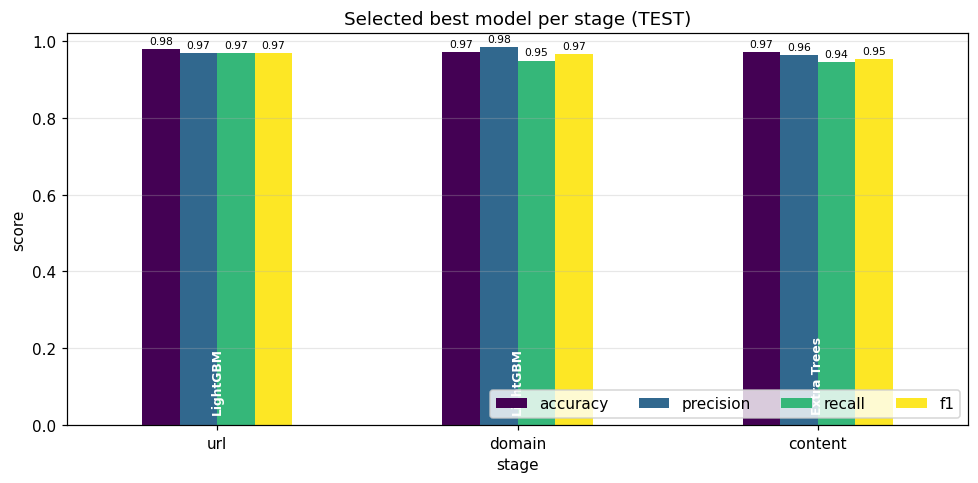

,best_model,precision,recall,f1,accuracy,roc_auc
stage,,,,,,
url,LightGBM,0.9672,0.9672,0.9672,0.9789,0.9966
domain,LightGBM,0.9831,0.9489,0.9657,0.9715,0.9952
content,Extra Trees,0.9626,0.9440,0.9532,0.9719,0.9917


In [73]:
REPORT_COLS = ["precision", "recall", "f1", "accuracy", "roc_auc"]

# full per-stage comparison tables (every candidate, sorted by the selection metric)
for stage in STAGES:
    print(f"\n===== {stage}  (best: {selected[stage]}) =====")
    print(stage_tables[stage].round(4).to_string(index=False))

# best-per-stage summary (the models the cascade will use)
per_stage = pd.DataFrame([
    {"stage": s, "best_model": selected[s],
     **stage_tables[s].set_index("model").loc[selected[s], REPORT_COLS].to_dict()}
    for s in STAGES
]).set_index("stage")
print("\nBest model per stage (test split):")
print(per_stage.round(4).to_string())

# bar chart of the selected winners' headline metrics
ax = per_stage[["accuracy","precision", "recall", "f1"]].plot(
    kind="bar", figsize=(9, 4.5), ylim=(0, 1.02), rot=0, colormap="viridis")
ax.set_title("Selected best model per stage (TEST)")
ax.set_xlabel("stage"); ax.set_ylabel("score"); ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", ncol=4)
for i, s in enumerate(STAGES):          # annotate each group with the winning model name
    ax.annotate(selected[s], (i, 0.03), ha="center", va="bottom", rotation=90,
                fontsize=8, color="white", fontweight="bold")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f", padding=2, fontsize=7)
plt.tight_layout(); plt.show()
per_stage.round(4)

## Score per-URL stage probabilities and assemble the cascade inputs

For each URL we build the ordered list `[("url", p), ("domain", p), ("content", p)]`,
**omitting** any stage that produced no features (`domain_ok` / `content_ok` False) -- the
cascade treats a stage with no usable probability as "escalate", so it must not appear.

In [74]:
def stage_probs_for(idx):
    '''Per-URL ordered [(stage, P(phish)), ...] for the rows in `idx`.'''
    pu = phish_proba(url_model, url_df.iloc[idx])
    pd_ = phish_proba(dom_model, dom_df.iloc[idx])
    pc = phish_proba(con_model, con_df.iloc[idx])
    dok = meta["domain_ok"].to_numpy()[idx]
    cok = meta["content_ok"].to_numpy()[idx]
    out = []
    for k in range(len(idx)):
        lst = [("url", float(pu[k]))]
        if dok[k]:
            lst.append(("domain", float(pd_[k])))
        if cok[k]:
            lst.append(("content", float(pc[k])))
        out.append(lst)
    return out

test_probs = stage_probs_for(test_idx)
y_test     = y[test_idx]
print(f"assembled prob lists: test={len(test_probs)}")
print("example (test[0]):", test_probs[0])

assembled prob lists: test=1615
example (test[0]): [('url', 0.9999781142871299), ('domain', 0.9996347338844087), ('content', 1.0)]


## Cascade replay (reuses the production decision logic)

`cascade()` rebuilds the `(stage, p)` list and `early_exit` exactly as the loop in
`Pipeline.run` does, then defers to `Pipeline._build_result` for the verdict -- the same
aggregation and the fixed `FALLBACK_DECISION_BOUNDARY`. So the offline verdict is identical
to production by construction; only the early-exit threshold is varied.

Note the documented invariant: with `max` aggregation the cascade reduces to
`phish  <=>  max(stage probs) >= min(threshold, 0.5)`, so thresholds above 0.5 are
equivalent and the meaningful knob lives in `(0, 0.5]`. The sweep curve makes this visible
(a flat region above 0.5).

In [75]:
_replay = Pipeline(stages=[], decision=DECISION)
_ctx = PipelineContext(url="", normalized_url="", domain="")

def cascade(prob_list, threshold):
    '''Return (decision, stage_id, route) for one URL at a given early-exit threshold.'''
    collected, early_exit = [], None
    for sid, p in prob_list:
        collected.append((sid, p))
        if p >= threshold:
            early_exit = (sid, p)
            break
    res = _replay._build_result(_ctx, collected, early_exit)
    if early_exit is not None:
        route = "early_exit"
    elif res.decision == "unknown":
        route = "unknown"
    else:
        route = "fallback"
    return res.decision, res.stage_id, route

# spot-check: the URL with the highest url probability should early-exit phish at 0.5
_demo = max(test_probs, key=lambda L: L[0][1])
print("highest-url-prob demo:", _demo, "->", cascade(_demo, 0.5))

highest-url-prob demo: [('url', 0.9999995578607562), ('domain', 0.9999982527873613), ('content', 1.0)] -> ('phish', 'url', 'early_exit')


## Threshold sweep on the test split

For every candidate threshold we replay the cascade over all test URLs and score the
phishing class (`phish = positive`; an `unknown` verdict counts as negative and is tallied
separately). The headline "optimal" is the **max-F1** threshold. With no separate
validation split the sweep runs on the test data itself, so this "optimal" is an in-sample
estimate.

In [76]:
def evaluate(prob_lists, y_true, threshold):
    preds, routes = [], []
    for L in prob_lists:
        dec, _sid, route = cascade(L, threshold)
        preds.append(1 if dec == POSITIVE else 0)
        routes.append(route)
    preds = np.asarray(preds)
    return {
        "threshold":  threshold,
        "precision":  precision_score(y_true, preds, zero_division=0),
        "recall":     recall_score(y_true, preds, zero_division=0),
        "f1":         f1_score(y_true, preds, zero_division=0),
        "accuracy":   accuracy_score(y_true, preds),
        "pred_phish": int(preds.sum()),
        "n_unknown":  int(sum(r == "unknown" for r in routes)),
    }

sweep = pd.DataFrame([evaluate(test_probs, y_test, t) for t in THRESHOLDS])
best_row = sweep.loc[sweep["f1"].idxmax()]
BEST_T = float(best_row["threshold"])
print(f"test F1-optimal threshold = {BEST_T:.4f}  "
      f"(F1={best_row['f1']:.4f}  P={best_row['precision']:.4f}  R={best_row['recall']:.4f})")

# secondary operating point: best precision while recall >= RECALL_TARGET
ok = sweep[sweep["recall"] >= RECALL_TARGET]
if len(ok):
    alt = ok.loc[ok["precision"].idxmax()]
    print(f"best precision @ recall>={RECALL_TARGET}: threshold={alt['threshold']:.4f}  "
          f"(P={alt['precision']:.4f}  R={alt['recall']:.4f}  F1={alt['f1']:.4f})")
else:
    print(f"no threshold reaches recall >= {RECALL_TARGET}")

# show a coarse view of the curve plus the winning row
view = sweep.iloc[::5].copy()
if BEST_T not in set(view["threshold"]):
    view = pd.concat([view, best_row.to_frame().T]).sort_values("threshold")
view.round(4)

test F1-optimal threshold = 0.9900  (F1=0.9845  P=0.9864  R=0.9826)
best precision @ recall>=0.95: threshold=1.0000  (P=0.9922  R=0.9768  F1=0.9844)


,threshold,precision,recall,f1,accuracy,pred_phish,n_unknown
0,0.00,0.9672,0.9672,0.9672,0.9789,518.0,0.0
5,0.05,0.9358,0.9846,0.9595,0.9734,545.0,0.0
10,0.10,0.9344,0.9903,0.9616,0.9746,549.0,0.0
15,0.15,0.9344,0.9903,0.9616,0.9746,549.0,0.0
20,0.20,0.9344,0.9903,0.9616,0.9746,549.0,0.0
25,0.25,0.9344,0.9903,0.9616,0.9746,549.0,0.0
30,0.30,0.9344,0.9903,0.9616,0.9746,549.0,0.0
35,0.35,0.9327,0.9903,0.9607,0.9740,550.0,0.0
40,0.40,0.9313,0.9942,0.9617,0.9746,553.0,0.0
45,0.45,0.9296,0.9942,0.9608,0.9740,554.0,0.0


## Metrics vs. threshold (test)

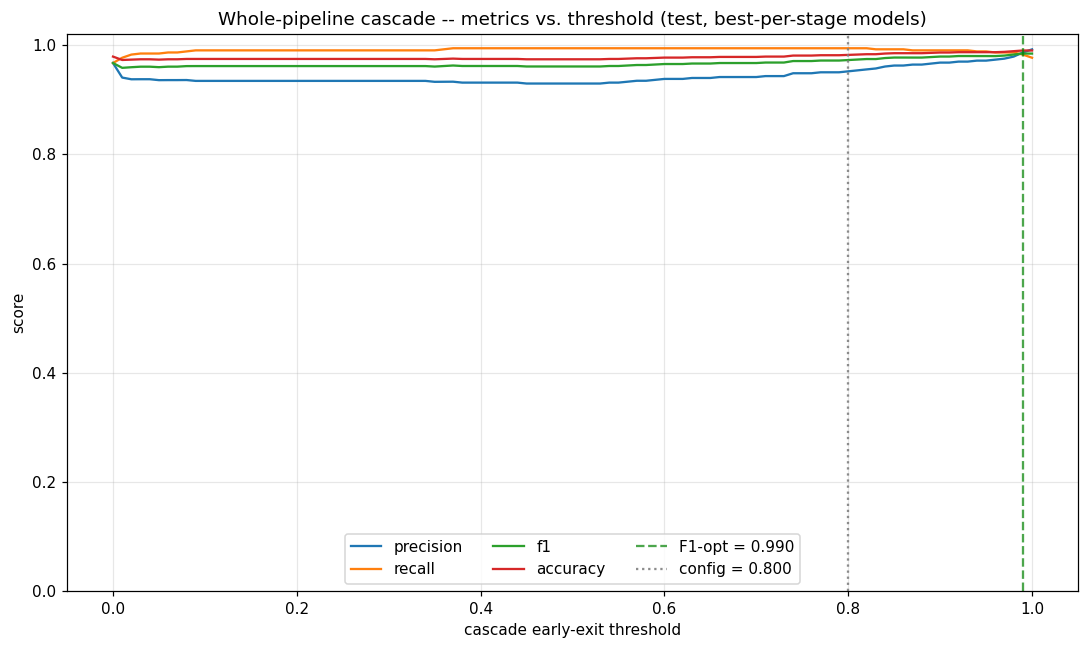

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(sweep["threshold"], sweep[m], label=m, color=c)
ax.axvline(BEST_T, ls="--", color="green", alpha=0.7, label=f"F1-opt = {BEST_T:.3f}")
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9,
           label=f"config = {CURRENT_THRESHOLD:.3f}")
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("score")
ax.set_title("Whole-pipeline cascade -- metrics vs. threshold (test, best-per-stage models)")
ax.set_ylim(0, 1.02); ax.grid(alpha=0.3); ax.legend(loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

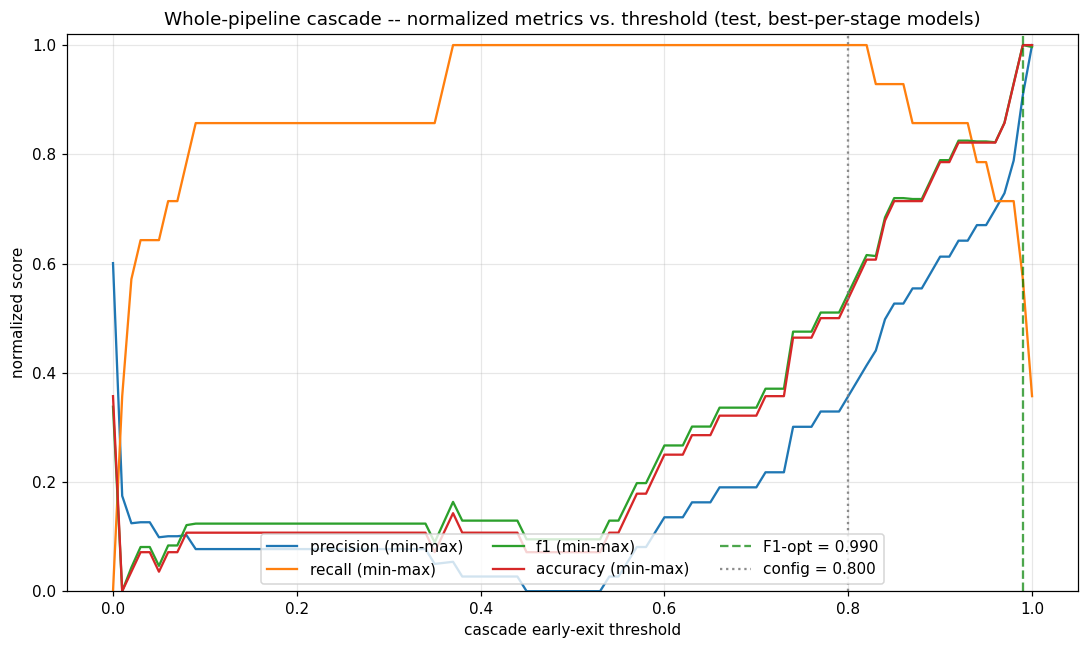

In [78]:
# Min-max normalize each metric across thresholds to compare shapes.
metrics = ["precision", "recall", "f1", "accuracy"]
norm = sweep[["threshold", *metrics]].copy()
for m in metrics:
    vals = norm[m].to_numpy()
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    if np.isclose(vmax - vmin, 0):
        norm[m] = 0.0
    else:
        norm[m] = (vals - vmin) / (vmax - vmin)

fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(norm["threshold"], norm[m], label=f"{m} (min-max)", color=c)
ax.axvline(BEST_T, ls="--", color="green", alpha=0.7, label=f"F1-opt = {BEST_T:.3f}")
ax.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9,
           label=f"config = {CURRENT_THRESHOLD:.3f}")
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("normalized score")
ax.set_title(
    "Whole-pipeline cascade -- normalized metrics vs. threshold (test, best-per-stage models)"
 )
ax.set_ylim(0, 1.02); ax.grid(alpha=0.3); ax.legend(loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

## Final report on the test split

Apply the F1-optimal threshold to the **test** split and compare it against the shipped
`decision.threshold`, so the recommended config change is explicit. Since there is no
separate validation split, this is the same data the threshold was tuned on, so read the
F1-optimal row as an in-sample best case.

In [79]:
def predict_at(prob_lists, threshold):
    return np.asarray([1 if cascade(L, threshold)[0] == POSITIVE else 0 for L in prob_lists])

def metrics_at(y_true, preds):
    return {"precision": precision_score(y_true, preds, zero_division=0),
            "recall":    recall_score(y_true, preds, zero_division=0),
            "f1":        f1_score(y_true, preds, zero_division=0),
            "accuracy":  accuracy_score(y_true, preds)}

preds_opt = predict_at(test_probs, BEST_T)
preds_cur = predict_at(test_probs, CURRENT_THRESHOLD)
cm_opt, cm_cur = confusion_matrix(y_test, preds_opt), confusion_matrix(y_test, preds_cur)

print(f"=== TEST @ F1-optimal threshold = {BEST_T:.4f} ===")
print(classification_report(y_test, preds_opt, target_names=[NEGATIVE, POSITIVE], digits=4))
print(f"=== TEST @ shipped config threshold = {CURRENT_THRESHOLD} ===")
print(classification_report(y_test, preds_cur, target_names=[NEGATIVE, POSITIVE], digits=4))

summary = pd.DataFrame([
    {"which": "F1-optimal",       "threshold": BEST_T,            **metrics_at(y_test, preds_opt)},
    {"which": "config (shipped)", "threshold": CURRENT_THRESHOLD, **metrics_at(y_test, preds_cur)},
]).set_index("which")
summary.round(4)

=== TEST @ F1-optimal threshold = 0.9900 ===
              precision    recall  f1-score   support

      benign     0.9918    0.9936    0.9927      1097
       phish     0.9864    0.9826    0.9845       518

    accuracy                         0.9901      1615
   macro avg     0.9891    0.9881    0.9886      1615
weighted avg     0.9901    0.9901    0.9901      1615

=== TEST @ shipped config threshold = 0.8 ===
              precision    recall  f1-score   support

      benign     0.9972    0.9763    0.9866      1097
       phish     0.9519    0.9942    0.9726       518

    accuracy                         0.9820      1615
   macro avg     0.9746    0.9853    0.9796      1615
weighted avg     0.9827    0.9820    0.9821      1615



,threshold,precision,recall,f1,accuracy
which,,,,,
F1-optimal,0.99,0.9864,0.9826,0.9845,0.9901
config (shipped),0.80,0.9519,0.9942,0.9726,0.9820


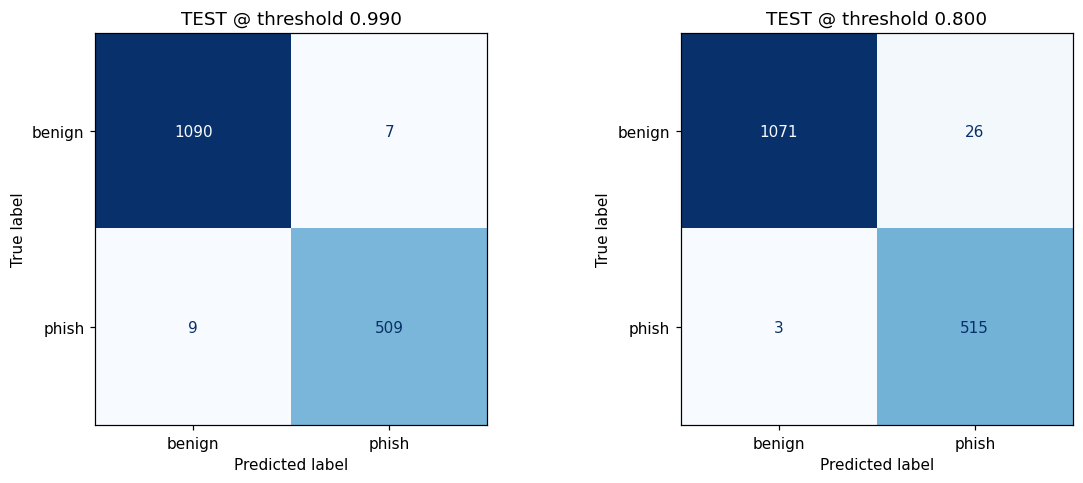

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, t in [(axes[0], cm_opt, BEST_T), (axes[1], cm_cur, CURRENT_THRESHOLD)]:
    ConfusionMatrixDisplay(cm, display_labels=[NEGATIVE, POSITIVE]).plot(
        cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"TEST @ threshold {t:.3f}")
plt.tight_layout(); plt.show()

## Cascade decision funnel

How each test URL was decided at the optimal threshold: which stage early-exited it to
`phish`, or whether it fell through to the aggregated fallback. The counts sum to the
number of evaluated URLs.

How the 1615 TEST URLs were decided at threshold 0.9900:


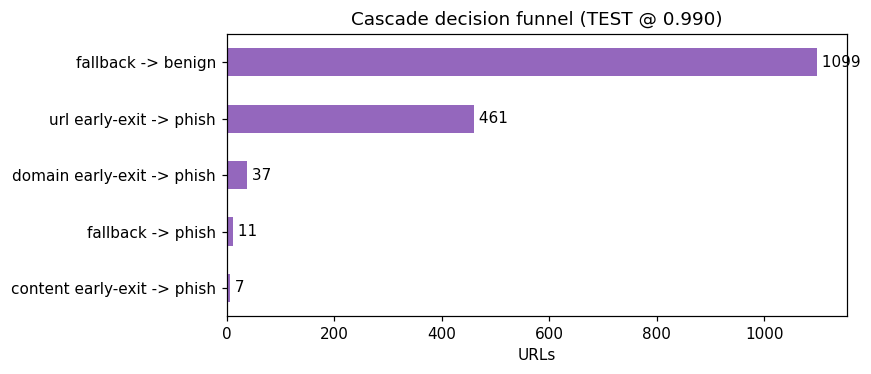

fallback -> benign             1099
url early-exit -> phish         461
domain early-exit -> phish       37
fallback -> phish                11
content early-exit -> phish       7
dtype: int64

In [81]:
routes = Counter()
for L in test_probs:
    dec, sid, route = cascade(L, BEST_T)
    if route == "early_exit":
        key = f"{sid} early-exit -> phish"
    elif route == "fallback":
        key = f"fallback -> {dec}"
    else:
        key = "unknown"
    routes[key] += 1

funnel = pd.Series(routes).sort_values(ascending=False)
assert funnel.sum() == len(test_probs)
print(f"How the {len(test_probs)} TEST URLs were decided at threshold {BEST_T:.4f}:")
ax = funnel.iloc[::-1].plot(kind="barh", figsize=(8, 3.5), color="tab:purple")
ax.set_xlabel("URLs"); ax.set_title(f"Cascade decision funnel (TEST @ {BEST_T:.3f})")
for i, v in enumerate(funnel.iloc[::-1].values):
    ax.text(v, i, f" {v}", va="center")
plt.tight_layout(); plt.show()
funnel

## Save results and close

Writes the sweep table, the test summary, and the recommended threshold to `eval_results/`
(git-ignored). To adopt the optimum, set `pipeline.decision.threshold` in
`config/pipeline.json` to the value printed below.

In [82]:
os.makedirs("eval_results", exist_ok=True)
sweep.to_csv("eval_results/pipeline_threshold_sweep.csv", index=False)
summary.to_csv("eval_results/pipeline_threshold_summary.csv")
per_stage.to_csv("eval_results/pipeline_per_stage_model_report.csv")
for stage in STAGES:
    stage_tables[stage].to_csv(f"eval_results/pipeline_model_comparison_{stage}.csv", index=False)
with open("eval_results/optimal_threshold.txt", "w") as fh:
    print(f"selection_metric={SELECTION_METRIC}", file=fh)
    for s in STAGES:
        print(f"selected_model_{s}={selected[s]}", file=fh)
    print(f"f1_optimal_threshold={BEST_T:.4f}", file=fh)
    print(f"config_threshold={CURRENT_THRESHOLD}", file=fh)
print("saved sweep + summary + per-stage report + per-stage model comparisons + "
      "optimal_threshold to eval_results/")
print()
print("selected models:", MODEL_DESC)
print(f">>> Recommended decision.threshold = {BEST_T:.4f}")
print("    (set it in config/pipeline.json -> pipeline.decision.threshold)")
store.close()
print("done")

saved sweep + summary + per-stage report + per-stage model comparisons + optimal_threshold to eval_results/

selected models: url:LightGBM | domain:LightGBM | content:Extra Trees
>>> Recommended decision.threshold = 0.9900
    (set it in config/pipeline.json -> pipeline.decision.threshold)
done


## Latency vs. F1 trade-off (uses measured per-stage mean latency)

Combines this notebook's **F1-vs-threshold** sweep with the **per-stage mean latency** measured by
`latency_evaluation.ipynb` (read from `eval_results/latency_summary.csv`) to estimate the **expected
end-to-end latency per URL** as the cascade threshold varies.

For each URL we walk the **production cascade order** (`config.pipeline.stages` = url -> content ->
domain) and add a stage's mean latency for every stage it *visits*, stopping at the first stage whose
`P(phish) >= threshold` (early-exit). Raising the threshold makes fewer URLs early-exit, so more
escalate to the expensive `content`/`domain` stages -> higher latency. F1 is order-independent (it
only depends on whether *any* stage crosses the threshold), so the existing sweep is reused as-is and
each URL's stage list is just reordered into production order for the latency walk.

Caveats: latency uses the **success-only mean** per stage from the current (sequential) collector and
counts only the stages each URL actually has features for (mirroring the routing). It estimates the
*relative* cost across thresholds, not a production SLA.

In [83]:
# --- per-stage mean TOTAL latency measured by latency_evaluation.ipynb ---
LAT_CSV = "eval_results/latency_summary.csv"
_lat = pd.read_csv(LAT_CSV)
LAT_MS = _lat[_lat["phase"] == "total"].set_index("stage")["mean_ms"].to_dict()
CASCADE_ORDER = [s.id for s in config.pipeline.stages]          # production order
print("cascade order:", CASCADE_ORDER)
print("per-stage mean total latency (ms):",
      {k: round(LAT_MS.get(k, float("nan")), 1) for k in CASCADE_ORDER})

_rank = {s: i for i, s in enumerate(CASCADE_ORDER)}

def _order(prob_list):
    # reorder a URL's [(stage, p), ...] into production cascade order
    return sorted(prob_list, key=lambda sp: _rank.get(sp[0], 99))

test_probs_ord = [_order(L) for L in test_probs]

def url_latency_ms(prob_list_ord, threshold):
    # sum mean latency of stages visited until the first early-exit (p >= threshold), else all
    total = 0.0
    for sid, p in prob_list_ord:
        total += LAT_MS.get(sid, 0.0)
        if p >= threshold:
            break
    return total

def latency_stats(threshold):
    lat = np.array([url_latency_ms(L, threshold) for L in test_probs_ord])
    return {"mean_latency_ms": float(lat.mean()),
            "median_latency_ms": float(np.median(lat)),
            "p95_latency_ms": float(np.percentile(lat, 95))}

tradeoff = sweep.merge(
    pd.DataFrame([{"threshold": t, **latency_stats(t)} for t in THRESHOLDS]), on="threshold")
print("\ntrade-off table (every 10th threshold):")
print(tradeoff[["threshold", "precision", "recall", "f1", "mean_latency_ms", "p95_latency_ms"]]
      .iloc[::10].round(3).to_string(index=False))

cascade order: ['url', 'content', 'domain']
per-stage mean total latency (ms): {'url': 19.0, 'content': 1041.6, 'domain': 2795.5}

trade-off table (every 10th threshold):
 threshold  precision  recall    f1  mean_latency_ms  p95_latency_ms
       0.0      0.967   0.967 0.967           19.010           19.01
       0.1      0.934   0.990 0.962         2389.761         3856.10
       0.2      0.934   0.990 0.962         2471.083         3856.10
       0.3      0.934   0.990 0.962         2521.689         3856.10
       0.4      0.931   0.994 0.962         2538.116         3856.10
       0.5      0.930   0.994 0.961         2560.382         3856.10
       0.6      0.938   0.994 0.965         2578.540         3856.10
       0.7      0.941   0.994 0.967         2589.130         3856.10
       0.8      0.952   0.994 0.973         2599.720         3856.10
       0.9      0.968   0.990 0.979         2625.855         3856.10
       1.0      0.992   0.977 0.984         3234.812         3856.10


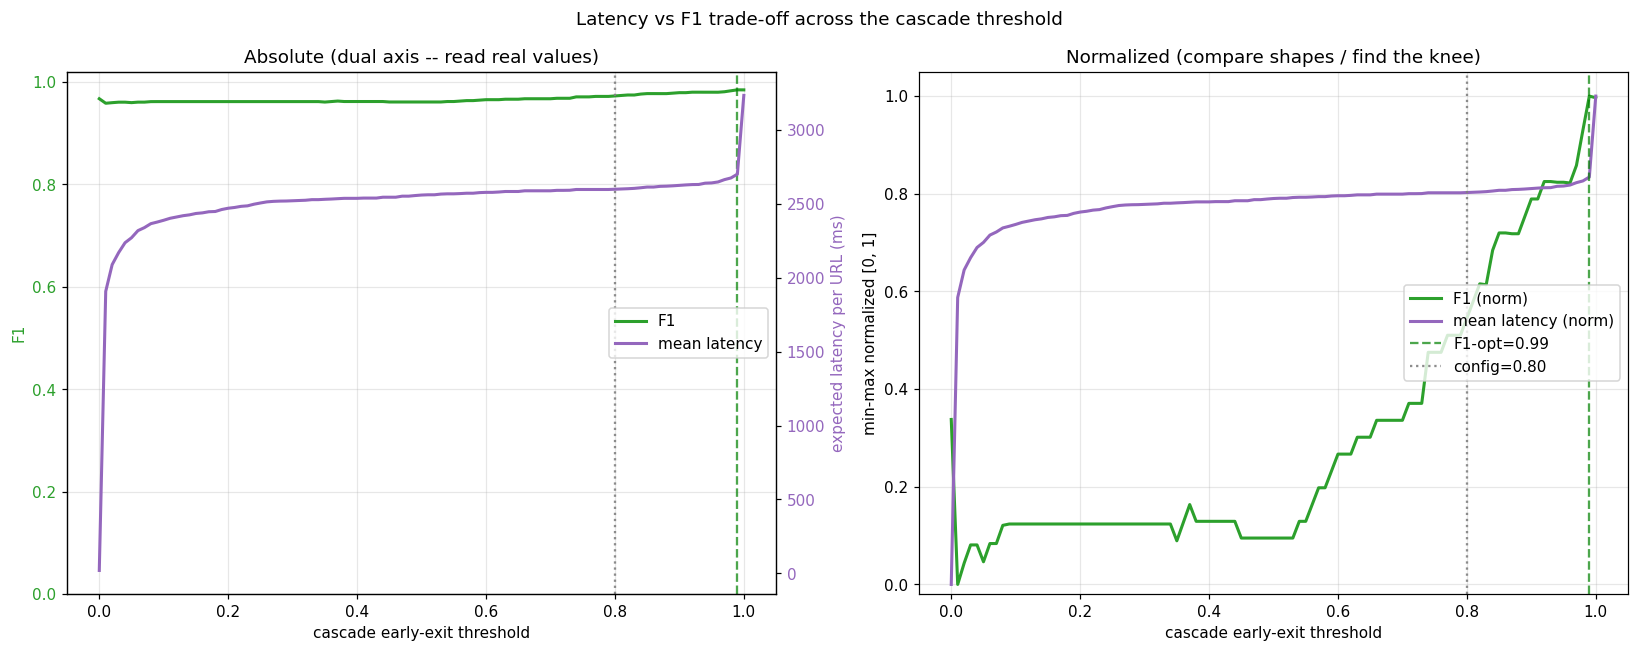

In [84]:
# Compare F1 vs expected latency across the threshold: absolute (dual-axis) + normalized (shapes).
def _minmax(v):
    v = np.asarray(v, dtype=float)
    lo, hi = np.nanmin(v), np.nanmax(v)
    return np.zeros_like(v) if np.isclose(hi, lo) else (v - lo) / (hi - lo)

fig, (axL, axN) = plt.subplots(1, 2, figsize=(15, 6))

# --- left: absolute, dual-axis (real F1 and real ms) ---
axL.plot(tradeoff["threshold"], tradeoff["f1"], color="tab:green", lw=2, label="F1")
axL.set_xlabel("cascade early-exit threshold")
axL.set_ylabel("F1", color="tab:green"); axL.set_ylim(0, 1.02)
axL.tick_params(axis="y", labelcolor="tab:green"); axL.grid(alpha=0.3)
axLr = axL.twinx()
axLr.plot(tradeoff["threshold"], tradeoff["mean_latency_ms"], color="tab:purple", lw=2, label="mean latency")
axLr.set_ylabel("expected latency per URL (ms)", color="tab:purple")
axLr.tick_params(axis="y", labelcolor="tab:purple")
axL.axvline(BEST_T, ls="--", color="green", alpha=0.7)
axL.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9)
h1, l1 = axL.get_legend_handles_labels(); h2, l2 = axLr.get_legend_handles_labels()
axL.legend(h1 + h2, l1 + l2, loc="center right")
axL.set_title("Absolute (dual axis -- read real values)")

# --- right: min-max normalized to [0,1] so shapes are directly comparable (cf. the metrics cell) ---
axN.plot(tradeoff["threshold"], _minmax(tradeoff["f1"]), color="tab:green", lw=2, label="F1 (norm)")
axN.plot(tradeoff["threshold"], _minmax(tradeoff["mean_latency_ms"]), color="tab:purple", lw=2,
         label="mean latency (norm)")
axN.set_xlabel("cascade early-exit threshold"); axN.set_ylabel("min-max normalized [0, 1]")
axN.set_ylim(-0.02, 1.05); axN.grid(alpha=0.3)
axN.axvline(BEST_T, ls="--", color="green", alpha=0.7, label=f"F1-opt={BEST_T:.2f}")
axN.axvline(CURRENT_THRESHOLD, ls=":", color="gray", alpha=0.9, label=f"config={CURRENT_THRESHOLD:.2f}")
axN.legend(loc="center right")
axN.set_title("Normalized (compare shapes / find the knee)")

fig.suptitle("Latency vs F1 trade-off across the cascade threshold")
plt.tight_layout(); plt.show()

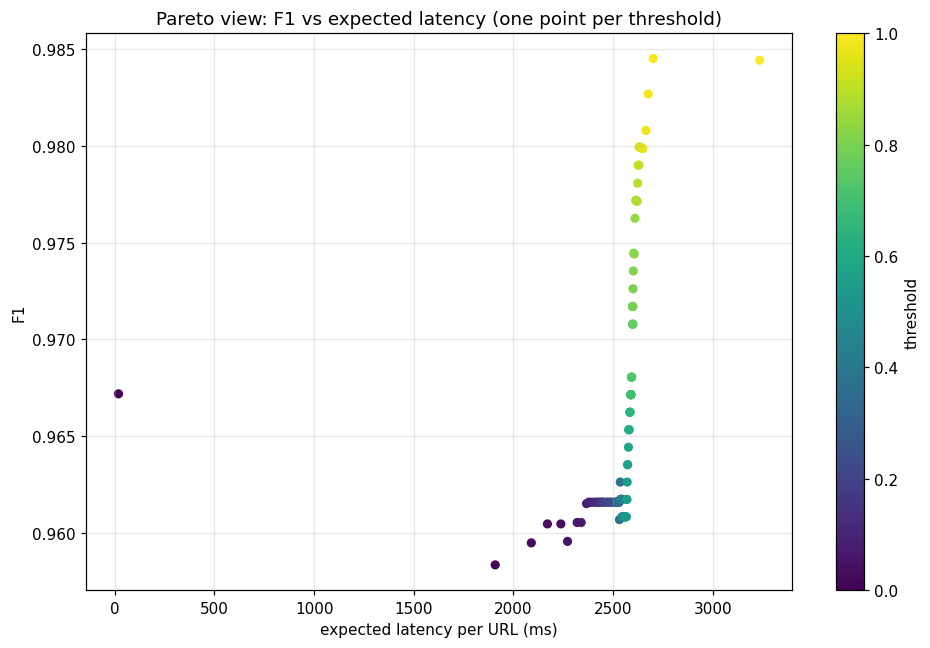

max F1 = 0.9845
>>> cheapest threshold within 0.01 F1 of max: t=0.840  F1=0.9763  mean_latency=2610 ms  p95=3856 ms


In [91]:
# Pareto view + a concrete trade-off pick
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(tradeoff["mean_latency_ms"], tradeoff["f1"], c=tradeoff["threshold"], cmap="viridis", s=25)
plt.colorbar(sc, label="threshold")
ax.set_xlabel("expected latency per URL (ms)"); ax.set_ylabel("F1")
ax.set_title("Pareto view: F1 vs expected latency (one point per threshold)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# trade-off pick: cheapest threshold within 0.01 F1 of the maximum
f1max = tradeoff["f1"].max()
cand = tradeoff[tradeoff["f1"] >= f1max - 0.01]
knee = cand.loc[cand["mean_latency_ms"].idxmin()]
print(f"max F1 = {f1max:.4f}")
print(f">>> cheapest threshold within 0.01 F1 of max: t={knee['threshold']:.3f}  "
      f"F1={knee['f1']:.4f}  mean_latency={knee['mean_latency_ms']:.0f} ms  p95={knee['p95_latency_ms']:.0f} ms")

In [86]:
tradeoff.to_csv("eval_results/latency_f1_tradeoff.csv", index=False)
print(f"saved {len(tradeoff)} rows -> eval_results/latency_f1_tradeoff.csv")

saved 101 rows -> eval_results/latency_f1_tradeoff.csv


## Optimal threshold = where the normalized F1 and latency curves cross

Following the normalized plot above, the optimal threshold is the **crossing point** of the two
min-max-normalized curves -- where normalized F1 rises to meet normalized latency. That is the best
F1 you can reach **before latency makes its final climb**.

Robustness: the curves also touch at the `t=1.0` corner (both hit their max there) and there is a
spurious crossing near `t->0` from the degenerate "flag-everything" spike. So we (a) drop degenerate
thresholds (flag >= `DEGEN_PHISH_RATE` as phish), (b) keep only crossings where F1 is *rising*, and
(c) among those take the **highest-F1** crossing. If there is no clean crossing we fall back to the
threshold where the two normalized curves come closest (excluding the corner).

In [87]:
# --- optimal threshold = crossing of the normalized F1 / latency curves (see plot above) ---
DEGEN_PHISH_RATE = 0.98     # thresholds flagging >= this share as phish are degenerate (dropped)

tr = tradeoff.sort_values("threshold").reset_index(drop=True)
thr = tr["threshold"].to_numpy()

def _mm(v):
    v = np.asarray(v, float); lo, hi = np.nanmin(v), np.nanmax(v)
    return np.zeros_like(v) if np.isclose(hi, lo) else (v - lo) / (hi - lo)

f1n  = _mm(tr["f1"])
latn = _mm(tr["mean_latency_ms"])
if "pred_phish" in tr.columns:
    degenerate = (tr["pred_phish"] / len(test_probs) >= DEGEN_PHISH_RATE).to_numpy()
else:
    degenerate = thr < 0.02

d = f1n - latn
cr = []
for i in np.where(d[:-1] * d[1:] < 0)[0]:                 # strict sign changes
    t0, t1, d0, d1 = thr[i], thr[i + 1], d[i], d[i + 1]
    tc = t0 - d0 * (t1 - t0) / (d1 - d0)                  # interpolate where the curves cross
    j = int(np.abs(thr - tc).argmin())
    rising = f1n[min(j + 1, len(f1n) - 1)] >= f1n[max(j - 1, 0)]
    if not degenerate[j] and rising:
        cr.append((tc, j))

if cr:
    tc, j = max(cr, key=lambda c: tr["f1"].iloc[c[1]])    # the best-F1 crossing
    how = f"crossing (interp t={tc:.3f})"
else:                                                     # fallback: closest approach, skip the corner
    mask = (~degenerate) & (thr < thr.max())
    sel = np.where(mask)[0]
    j = int(sel[np.abs(d[sel]).argmin()]); tc = float(thr[j])
    how = "closest approach (no clean crossing)"

opt = tr.iloc[j]
T_CROSS = float(opt["threshold"])
pr = (opt["pred_phish"] / len(test_probs)) if "pred_phish" in tr.columns else float("nan")

print(f"normalized curves: {len(cr)} clean crossing(s); using {how}")
print(f">>> OPTIMAL threshold (F1/latency crossing) = {T_CROSS:.3f}")
print(f"      F1={opt['f1']:.4f}  precision={opt['precision']:.4f}  recall={opt['recall']:.4f}  "
      f"mean_latency={opt['mean_latency_ms']:.0f} ms  p95={opt['p95_latency_ms']:.0f} ms  flagged_phish={pr:.0%}")
bi = int((tr["threshold"] - BEST_T).abs().idxmin()); ci = int((tr["threshold"] - CURRENT_THRESHOLD).abs().idxmin())
print(f"    vs F1-optimal t={BEST_T:.3f} (F1={tr['f1'].iloc[bi]:.4f}, {tr['mean_latency_ms'].iloc[bi]:.0f} ms)"
      f"  |  config t={CURRENT_THRESHOLD:.3f} (F1={tr['f1'].iloc[ci]:.4f}, {tr['mean_latency_ms'].iloc[ci]:.0f} ms)")

normalized curves: 1 clean crossing(s); using crossing (interp t=0.916)
>>> OPTIMAL threshold (F1/latency crossing) = 0.920
      F1=0.9799  precision=0.9698  recall=0.9903  mean_latency=2631 ms  p95=3856 ms  flagged_phish=33%
    vs F1-optimal t=0.990 (F1=0.9845, 2702 ms)  |  config t=0.800 (F1=0.9726, 2600 ms)


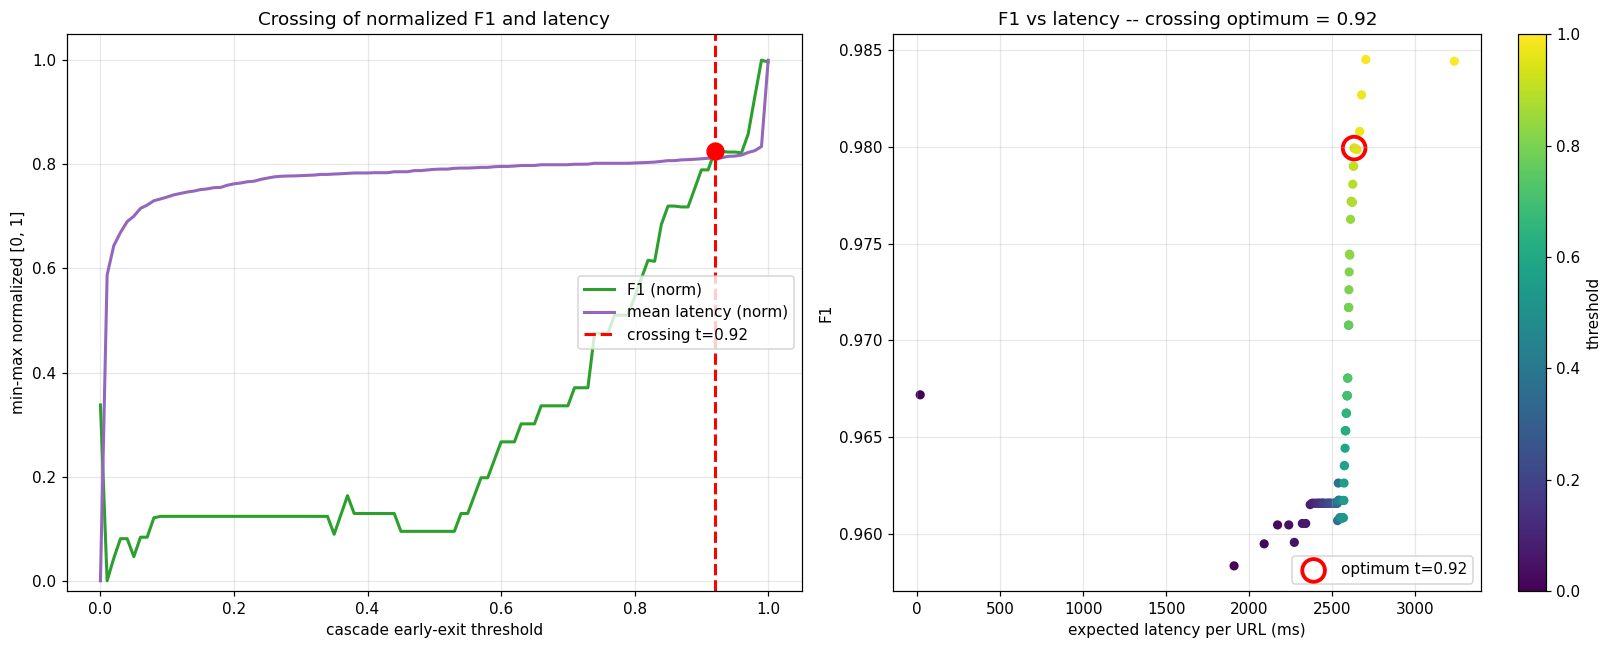

>>> Recommended decision.threshold (normalized F1/latency crossing) = 0.920
    set it in config/pipeline.json -> pipeline.decision.threshold


In [88]:
fig, (axN, axP) = plt.subplots(1, 2, figsize=(15, 6))

# left: the normalized curves with the crossing marked
axN.plot(thr, f1n, color="tab:green", lw=2, label="F1 (norm)")
axN.plot(thr, latn, color="tab:purple", lw=2, label="mean latency (norm)")
axN.axvline(T_CROSS, color="red", ls="--", lw=2, label=f"crossing t={T_CROSS:.2f}")
axN.scatter([T_CROSS], [f1n[j]], s=120, color="red", zorder=5)
axN.set_xlabel("cascade early-exit threshold"); axN.set_ylabel("min-max normalized [0, 1]")
axN.set_ylim(-0.02, 1.05); axN.grid(alpha=0.3); axN.legend(loc="center right")
axN.set_title("Crossing of normalized F1 and latency")

# right: Pareto in real units with the crossing optimum
sc = axP.scatter(tr["mean_latency_ms"], tr["f1"], c=tr["threshold"], cmap="viridis", s=25)
plt.colorbar(sc, label="threshold", ax=axP)
axP.scatter([opt["mean_latency_ms"]], [opt["f1"]], s=220, edgecolor="red", facecolor="none", lw=2.5,
            label=f"optimum t={T_CROSS:.2f}")
axP.set_xlabel("expected latency per URL (ms)"); axP.set_ylabel("F1")
axP.grid(alpha=0.3); axP.legend(loc="lower right")
axP.set_title(f"F1 vs latency -- crossing optimum = {T_CROSS:.2f}")
plt.tight_layout(); plt.show()

tradeoff.to_csv("eval_results/latency_f1_tradeoff.csv", index=False)
print(f">>> Recommended decision.threshold (normalized F1/latency crossing) = {T_CROSS:.3f}")
print("    set it in config/pipeline.json -> pipeline.decision.threshold")